# Manipulation des Données Climatiques avec Pandas

Ce notebook présente les techniques de manipulation de données avec Pandas appliquées aux données climatiques NOAA (2000-2025).

## Objectifs
1. Charger et explorer les données brutes
2. Nettoyer et prétraiter les données
3. Effectuer des agrégations et des transformations
4. Analyser les tendances temporelles
5. Préparer les données pour la visualisation

## 1. Import des bibliothèques nécessaires

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 1000)

# Désactiver les avertissements
import warnings
warnings.filterwarnings('ignore')

## 2. Chargement des données brutes

Nous allons charger les fichiers CSV des années 2000 à 2025.

In [6]:
# Chemin vers les données
data_path = '../data_noaa'

# Liste tous les fichiers CSV
csv_files = glob.glob(os.path.join(data_path, '*.csv'))

# Affiche les fichiers trouvés
print(f"Nombre de fichiers CSV trouvés : {len(csv_files)}")
print("\nPremiers fichiers :")
for file in sorted(csv_files)[:5]:
    print(f"- {os.path.basename(file)}")

Nombre de fichiers CSV trouvés : 26

Premiers fichiers :
- 2000.csv
- 2001.csv
- 2002.csv
- 2003.csv
- 2004.csv


### 2.1 Chargement d'un échantillon
Examinons d'abord le contenu d'un seul fichier pour comprendre sa structure.

In [7]:
# Charger le fichier de 2020 comme exemple
sample_df = pd.read_csv(os.path.join(data_path, '2020.csv'))

# Afficher les informations sur le DataFrame
print("Info du DataFrame :")
print("-" * 40)
sample_df.info()

print("\nPremières lignes :")
print("-" * 40)
display(sample_df.head())

print("\nDescription statistique :")
print("-" * 40)
display(sample_df.describe())

Info du DataFrame :
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36856008 entries, 0 to 36856007
Data columns (total 8 columns):
 #   Column      Dtype  
---  ------      -----  
 0   ID          object 
 1   DATE        int64  
 2   ELEMENT     object 
 3   DATA_VALUE  int64  
 4   M_FLAG      object 
 5   Q_FLAG      object 
 6   S_FLAG      object 
 7   OBS_TIME    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 2.2+ GB

Premières lignes :
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36856008 entries, 0 to 36856007
Data columns (total 8 columns):
 #   Column      Dtype  
---  ------      -----  
 0   ID          object 
 1   DATE        int64  
 2   ELEMENT     object 
 3   DATA_VALUE  int64  
 4   M_FLAG      object 
 5   Q_FLAG      object 
 6   S_FLAG      object 
 7   OBS_TIME    float64
dtypes: float64(1), int64(2), object(5)
memory usage: 2.2+ GB

Premières lignes :
------

,ID,DATE,ELEMENT,DATA_VALUE,M_FLAG,Q_FLAG,S_FLAG,OBS_TIME
0,BR038484280,20200101,TMAX,288,NaN,NaN,S,NaN
1,BR038484280,20200101,TAVG,247,H,NaN,S,NaN
2,BR038983570,20200101,TMAX,324,NaN,NaN,S,NaN
3,BR038983570,20200101,TMIN,240,NaN,NaN,S,NaN
4,BR038983570,20200101,PRCP,0,NaN,NaN,S,NaN



Description statistique :
----------------------------------------


,DATE,DATA_VALUE,OBS_TIME
count,3.685601e+07,3.685601e+07,1.695017e+07
mean,2.020067e+07,1.711033e+02,9.123377e+02
std,3.463397e+02,9.847864e+02,4.845372e+02
min,2.020010e+07,-7.830000e+02,0.000000e+00
25%,2.020040e+07,0.000000e+00,7.000000e+02
50%,2.020070e+07,5.000000e+00,7.000000e+02
75%,2.020100e+07,1.180000e+02,8.000000e+02
max,2.020123e+07,9.891700e+04,2.400000e+03


## 3. Nettoyage et prétraitement

Créons des fonctions pour nettoyer et standardiser nos données.

In [8]:
def clean_dataset(df):
    """Nettoie et prépare un DataFrame climatique"""
    # Copie pour éviter les modifications en place
    df = df.copy()
    
    # 1. Standardiser les noms de colonnes
    df.columns = df.columns.str.strip().str.upper()
    
    # 2. Convertir la date en datetime
    if 'DATE' in df.columns:
        df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
        df['YEAR'] = df['DATE'].dt.year
        df['MONTH'] = df['DATE'].dt.month
        df['DAY'] = df['DATE'].dt.day
    
    # 3. Nettoyer les valeurs manquantes
    df = df.dropna(subset=['ID', 'DATE', 'ELEMENT', 'DATA_VALUE'])
    
    # 4. Convertir DATA_VALUE en numérique
    df['DATA_VALUE'] = pd.to_numeric(df['DATA_VALUE'], errors='coerce')
    
    return df

# Tester la fonction sur notre échantillon
cleaned_sample = clean_dataset(sample_df)
display(cleaned_sample.head())
print("\nColonnes après nettoyage :", cleaned_sample.columns.tolist())

,ID,DATE,ELEMENT,DATA_VALUE,M_FLAG,Q_FLAG,S_FLAG,OBS_TIME,YEAR,MONTH,DAY
0,BR038484280,2020-01-01,TMAX,288,NaN,NaN,S,NaN,2020,1,1
1,BR038484280,2020-01-01,TAVG,247,H,NaN,S,NaN,2020,1,1
2,BR038983570,2020-01-01,TMAX,324,NaN,NaN,S,NaN,2020,1,1
3,BR038983570,2020-01-01,TMIN,240,NaN,NaN,S,NaN,2020,1,1
4,BR038983570,2020-01-01,PRCP,0,NaN,NaN,S,NaN,2020,1,1



Colonnes après nettoyage : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OBS_TIME', 'YEAR', 'MONTH', 'DAY']


## 4. Fusion des données

Maintenant, fusionnons tous les fichiers en un seul DataFrame.

In [10]:
def process_climate_data():
    """Traite les données climatiques année par année et crée les agrégations directement"""
    output_dir = '../data_noaa/processed'
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Initialiser les DataFrames d'agrégation
    yearly_data = []
    processed_years = set()  # Pour éviter le traitement en double
    
    # Définir les noms de colonnes pour les fichiers sans en-tête
    default_columns = ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OBS_TIME']
    
    # Traiter chaque fichier
    for file in sorted(csv_files):
        try:
            year = os.path.basename(file).split('.')[0]
            if year in processed_years:  # Éviter le traitement en double
                continue
                
            print(f"\nTraitement de l'année {year}...")
            
            # Essayer d'abord de lire avec pandas pour détecter le format
            try:
                df_sample = pd.read_csv(file, nrows=5)
                has_headers = all(col in df_sample.columns for col in ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE'])
                print(f"Format détecté : {'avec en-têtes' if has_headers else 'sans en-têtes'}")
                
                if not has_headers:
                    # Si pas d'en-têtes, utiliser les premières colonnes comme données
                    chunks = pd.read_csv(file, chunksize=100000, names=default_columns,
                                       usecols=[0, 1, 2, 3, 4, 5, 6, 7])  # Utiliser uniquement les 8 premières colonnes
                else:
                    chunks = pd.read_csv(file, chunksize=100000)
            
            except pd.errors.EmptyDataError:
                print(f"✗ Fichier vide : {file}")
                continue
                
            year_stats = {'TAVG': [], 'TMIN': [], 'TMAX': [], 'PRCP': []}
            year_stations = set()
            chunks_processed = 0
            total_rows = 0
            
            for chunk in chunks:
                # Nettoyer le chunk
                clean_chunk = clean_dataset(chunk)
                chunks_processed += 1
                total_rows += len(clean_chunk)
                
                # Collecter les statistiques
                for element in ['TAVG', 'TMIN', 'TMAX', 'PRCP']:
                    element_data = clean_chunk[clean_chunk['ELEMENT'] == element]
                    if not element_data.empty:
                        year_stats[element].extend(element_data['DATA_VALUE'].tolist())
                
                # Collecter les stations
                year_stations.update(clean_chunk['ID'].unique())
                
                # Afficher la progression tous les 10 chunks
                if chunks_processed % 10 == 0:
                    print(f"  Progression: {total_rows:,} lignes traitées...")
            
            # Calculer les statistiques annuelles
            if total_rows > 0:  # Seulement si des données ont été traitées
                yearly_stats = {
                    'YEAR': int(year),
                    'TAVG_mean': np.mean(year_stats['TAVG']) if year_stats['TAVG'] else None,
                    'TMIN_min': np.min(year_stats['TMIN']) if year_stats['TMIN'] else None,
                    'TMAX_max': np.max(year_stats['TMAX']) if year_stats['TMAX'] else None,
                    'PRCP_sum': np.sum(year_stats['PRCP']) if year_stats['PRCP'] else None,
                    'stations_count': len(year_stations)
                }
                yearly_data.append(yearly_stats)
                processed_years.add(year)  # Marquer l'année comme traitée
                print(f"✓ {year}: {len(year_stations):,} stations, {total_rows:,} mesures")
            else:
                print(f"✗ Aucune donnée valide trouvée pour {year}")
            
        except Exception as e:
            print(f"✗ Erreur avec {file}: {str(e)}")
            print(f"  Type d'erreur: {type(e).__name__}")
            continue  # Passer au fichier suivant en cas d'erreur
    
    # Créer et sauvegarder les données annuelles
    if yearly_data:
        yearly_df = pd.DataFrame(yearly_data)
        yearly_df = yearly_df.sort_values('YEAR')  # Trier par année
        yearly_df.to_csv(f"{output_dir}/annual_trends.csv", index=False)
        print(f"\nTendances annuelles sauvegardées dans {output_dir}/annual_trends.csv")
        return yearly_df
    else:
        print("Aucune donnée n'a pu être traitée.")
        return None

Début du traitement des données...

Traitement de l'année 2000...
Colonnes trouvées : ['BR038484280', '20000101', 'TAVG', '252', 'H', 'Unnamed: 5', 'S', 'Unnamed: 7']
✗ Erreur avec ../data_noaa\2000.csv: Colonnes manquantes : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE']
  Type d'erreur: ValueError

Traitement de l'année 2001...
Colonnes trouvées : ['BR038484280', '20010101', 'TMIN', '205', 'Unnamed: 4', 'Unnamed: 5', 'S', 'Unnamed: 7']
✗ Erreur avec ../data_noaa\2001.csv: Colonnes manquantes : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE']
  Type d'erreur: ValueError

Traitement de l'année 2002...
Colonnes trouvées : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OBS_TIME']
✓ 2002: 29,981 stations

Traitement de l'année 2003...
✓ 2002: 29,981 stations

Traitement de l'année 2003...
Colonnes trouvées : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OBS_TIME']
Colonnes trouvées : ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OB

,YEAR,TAVG_mean,TMIN_min,TMAX_max,PRCP_sum,stations_count
0,2002,110.349132,-999,5072,185542803,29981
1,2003,111.938469,-999,3376,200485588,30387
2,2004,108.985848,-999,4706,214365454,31324
3,2005,108.305767,-1493,12900,200239517,31477
4,2006,106.127126,-999,4435,204621839,32493
...,...,...,...,...,...,...
19,2021,104.910743,-796,696,309891707,43411
20,2022,104.922752,-777,12600,292307552,43529
21,2023,109.474889,-820,4822,297799200,43907
22,2024,114.114011,-2417,8078,320328554,43560


## 5. Analyse des tendances climatiques annuelles

Examinons les tendances climatiques sur l'ensemble de la période.

Statistiques descriptives des tendances annuelles :


,YEAR,TAVG_mean,TMIN_min,TMAX_max,PRCP_sum,stations_count
count,24.000000,24.000000,24.000000,24.000000,2.400000e+01,24.000000
mean,2013.500000,107.921216,-1115.083333,10264.500000,2.665441e+08,39201.666667
std,7.071068,4.830826,435.022630,16164.481145,4.248885e+07,4639.319859
min,2002.000000,101.938074,-2489.000000,644.000000,1.855428e+08,29981.000000
25%,2007.750000,104.919749,-999.000000,1062.250000,2.207399e+08,37176.000000
50%,2013.500000,106.798038,-999.000000,3388.000000,2.844137e+08,41411.000000
75%,2019.250000,109.689345,-990.000000,9208.500000,2.980237e+08,41950.500000
max,2025.000000,125.323156,-777.000000,55372.000000,3.203286e+08,43907.000000



Évolution du nombre de stations par année :


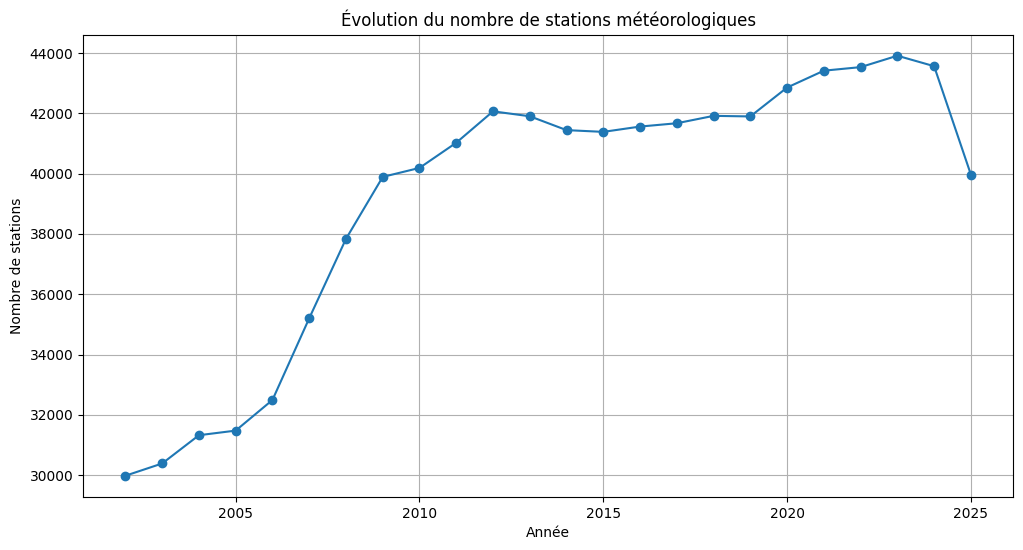


Tendances des températures moyennes, minimales et maximales :


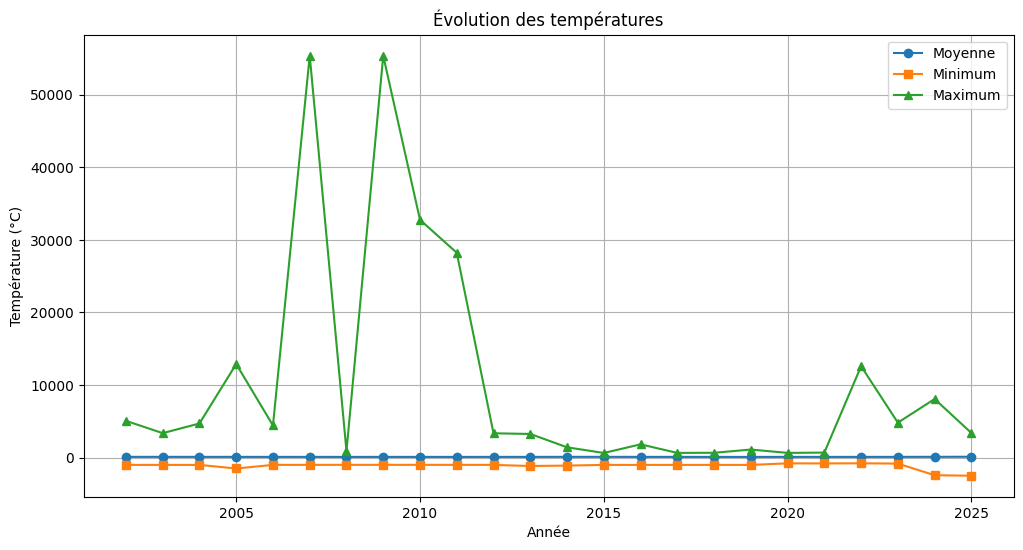

In [11]:
# Afficher les statistiques descriptives
print("Statistiques descriptives des tendances annuelles :")
display(annual_trends.describe())

# Évolution du nombre de stations
print("\nÉvolution du nombre de stations par année :")
plt.figure(figsize=(12, 6))
plt.plot(annual_trends['YEAR'], annual_trends['stations_count'], marker='o')
plt.title('Évolution du nombre de stations météorologiques')
plt.xlabel('Année')
plt.ylabel('Nombre de stations')
plt.grid(True)
plt.show()

# Tendances des températures
print("\nTendances des températures moyennes, minimales et maximales :")
plt.figure(figsize=(12, 6))
plt.plot(annual_trends['YEAR'], annual_trends['TAVG_mean'], label='Moyenne', marker='o')
plt.plot(annual_trends['YEAR'], annual_trends['TMIN_min'], label='Minimum', marker='s')
plt.plot(annual_trends['YEAR'], annual_trends['TMAX_max'], label='Maximum', marker='^')
plt.title('Évolution des températures')
plt.xlabel('Année')
plt.ylabel('Température (°C)')
plt.legend()
plt.grid(True)
plt.show()

## 6. Pivotement des données

Transformons les données du format long au format large pour faciliter l'analyse.

In [2]:
# Imports nécessaires
import pandas as pd
import numpy as np
from pathlib import Path
import glob
import os
import time
from datetime import datetime
import psutil

def get_memory_usage():
    """Retourne l'utilisation actuelle de la mémoire en GB"""
    process = psutil.Process(os.getpid())
    mem_usage = process.memory_info().rss / 1024 / 1024 / 1024  # Convertir en GB
    return mem_usage

def clean_dataset(df):
    """Nettoie et prépare un DataFrame climatique"""
    # Appliquer les opérations directement sans copie pour économiser la mémoire
    df.columns = df.columns.str.strip().str.upper()
    
    if 'DATE' in df.columns:
        # Convertir la date de manière plus efficace
        df['DATE'] = pd.to_datetime(df['DATE'].astype(str), format='%Y%m%d')
        # Extraire year, month, day en une seule opération
        df[['YEAR', 'MONTH', 'DAY']] = df['DATE'].dt.strftime('%Y-%m-%d').str.split('-', expand=True).astype(int)
    
    # Nettoyer les valeurs manquantes et convertir DATA_VALUE en une seule opération
    mask = df[['ID', 'DATE', 'ELEMENT', 'DATA_VALUE']].notna().all(axis=1)
    df = df[mask]
    df['DATA_VALUE'] = pd.to_numeric(df['DATA_VALUE'], errors='coerce')
    
    return df

def process_file_in_chunks(file, output_dir, chunk_size=500000):
    """Traite un fichier en chunks avec optimisation de la mémoire"""
    year = os.path.basename(file).split('.')[0]
    output_file = f"{output_dir}/climate_data_pivoted_{year}.csv"
    temp_file = f"{output_dir}/temp_{year}.csv"
    
    # Vérifier si le fichier est déjà traité
    if os.path.exists(output_file):
        print(f"\nL'année {year} est déjà traitée, on passe...")
        return True
    
    print(f"\nChargement de l'année {year}...")
    start_time = time.time()
    
    try:
        # Détecter le format du fichier
        df_sample = pd.read_csv(file, nrows=5)
        has_headers = all(col in df_sample.columns for col in ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE'])
        
        # Préparer les paramètres de lecture
        read_params = {
            'chunksize': chunk_size,
            'usecols': ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE'] if has_headers else [0, 1, 2, 3],
            'dtype': {
                'ID': 'category',
                'ELEMENT': 'category',
                'DATA_VALUE': 'float32'
            }
        }
        
        if not has_headers:
            read_params.update({
                'names': ['ID', 'DATE', 'ELEMENT', 'DATA_VALUE', 'M_FLAG', 'Q_FLAG', 'S_FLAG', 'OBS_TIME']
            })
        
        # Variables pour suivre la progression
        total_rows = 0
        chunks_processed = 0
        
        # Première passe : nettoyer et sauvegarder les données en format intermédiaire
        print("Phase 1: Nettoyage des données...")
        for chunk in pd.read_csv(file, **read_params):
            # Surveiller l'utilisation de la mémoire
            if get_memory_usage() > 6:  # Si plus de 6 GB utilisés
                print("  Nettoyage de la mémoire...")
                import gc
                gc.collect()
            
            chunk_clean = clean_dataset(chunk)
            
            # Sauvegarder en format intermédiaire
            mode = 'w' if chunks_processed == 0 else 'a'
            chunk_clean.to_csv(temp_file, mode=mode, index=False, header=(mode=='w'))
            
            chunks_processed += 1
            total_rows += len(chunk_clean)
            
            if chunks_processed % 5 == 0:
                elapsed_time = time.time() - start_time
                speed = total_rows / elapsed_time
                mem_usage = get_memory_usage()
                print(f"  Progression: {total_rows:,} lignes ({speed:.0f} lignes/sec, {mem_usage:.1f} GB RAM)")
        
        # Deuxième passe : créer le pivot
        print("\nPhase 2: Création du pivot...")
        chunks = pd.read_csv(temp_file, chunksize=chunk_size)
        first_chunk = True
        
        for chunk in chunks:
            pivot_chunk = chunk.pivot_table(
                index=['DATE', 'ID', 'YEAR', 'MONTH', 'DAY'],
                columns='ELEMENT',
                values='DATA_VALUE',
                aggfunc='mean'
            ).reset_index()
            
            # Sauvegarder le pivot
            pivot_chunk.to_csv(output_file, mode='w' if first_chunk else 'a',
                             header=first_chunk, index=False)
            first_chunk = False
        
        # Nettoyer les fichiers temporaires
        if os.path.exists(temp_file):
            os.remove(temp_file)
        
        elapsed_time = time.time() - start_time
        print(f"✓ {year} traité ({total_rows:,} lignes en {elapsed_time:.1f} secondes)")
        return True
        
    except Exception as e:
        print(f"✗ Erreur avec {file}: {str(e)}")
        # Nettoyer les fichiers en cas d'erreur
        for f in [output_file, temp_file]:
            if os.path.exists(f):
                os.remove(f)
        return False

# Créer le répertoire de sortie
output_dir = '../data_noaa/processed'
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Configuration pour un traitement plus rapide
pd.set_option('mode.chained_assignment', None)  # Désactiver les avertissements

# Afficher les ressources disponibles
print(f"Ressources disponibles :")
print(f"- RAM totale : {psutil.virtual_memory().total / 1024**3:.1f} GB")
print(f"- RAM disponible : {psutil.virtual_memory().available / 1024**3:.1f} GB")
print(f"- Espace disque disponible : {psutil.disk_usage(output_dir).free / 1024**3:.1f} GB")

print(f"\nDébut du traitement des données... ({datetime.now().strftime('%H:%M:%S')})")

# Traiter chaque fichier individuellement
files = sorted(glob.glob(os.path.join('../data_noaa', '*.csv')))
processed_years = 0
start_total = time.time()

for file in files:
    if process_file_in_chunks(file, output_dir):
        processed_years += 1
    
    # Forcer le nettoyage de la mémoire entre les fichiers
    import gc
    gc.collect()

elapsed_total = time.time() - start_total
print(f"\nTraitement terminé. {processed_years} années traitées en {elapsed_total:.1f} secondes")
print(f"Moyenne : {elapsed_total/processed_years:.1f} secondes par année")

# Afficher un exemple des données pivotées (dernière année traitée)
if processed_years > 0:
    recent_file = max(glob.glob(os.path.join(output_dir, 'climate_data_pivoted_*.csv')))
    sample_pivot = pd.read_csv(recent_file, nrows=5)
    print("\nAperçu des données pivotées (dernière année) :")
    display(sample_pivot)

Ressources disponibles :
- RAM totale : 15.9 GB
- RAM disponible : 5.4 GB
- Espace disque disponible : 199.6 GB

Début du traitement des données... (17:40:48)

L'année 2000 est déjà traitée, on passe...

Chargement de l'année 2001...
Phase 1: Nettoyage des données...
Phase 1: Nettoyage des données...
  Progression: 2,500,000 lignes (102114 lignes/sec, 5.3 GB RAM)
  Progression: 2,500,000 lignes (102114 lignes/sec, 5.3 GB RAM)
  Progression: 5,000,000 lignes (106253 lignes/sec, 5.3 GB RAM)
  Progression: 5,000,000 lignes (106253 lignes/sec, 5.3 GB RAM)
  Progression: 7,500,000 lignes (101948 lignes/sec, 5.3 GB RAM)
  Progression: 7,500,000 lignes (101948 lignes/sec, 5.3 GB RAM)
  Progression: 10,000,000 lignes (98681 lignes/sec, 5.3 GB RAM)
  Progression: 10,000,000 lignes (98681 lignes/sec, 5.3 GB RAM)
  Progression: 12,500,000 lignes (99652 lignes/sec, 5.3 GB RAM)
  Progression: 12,500,000 lignes (99652 lignes/sec, 5.3 GB RAM)
  Progression: 15,000,000 lignes (99536 lignes/sec, 5.3 GB

,DATE,ID,YEAR,MONTH,DAY,AWDR,AWND,DAPR,DATN,DATX,...,WSFI,WT01,WT02,WT03,WT04,WT05,WT06,WT08,WT09,WT11
0,2025-01-01,AE000041196,2025,1,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01,AEM00041194,2025,1,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01,AEM00041217,2025,1,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01,AEM00041218,2025,1,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01,AG000060390,2025,1,1,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. Agrégations

Créons différentes vues agrégées des données pour l'analyse.

In [9]:
# Charger les données pivotées
import pandas as pd
import glob
import os
import time
from datetime import datetime

def load_csv_safely(file, chunk_size=100000):
    """Charge un fichier CSV de manière sécurisée en gérant les erreurs de parsing"""
    print(f"Chargement de {os.path.basename(file)}...")
    
    try:
        # Premier essai avec des paramètres stricts
        return pd.read_csv(file, 
                         on_bad_lines='skip',  # Ignorer les lignes problématiques
                         low_memory=False,     # Éviter les problèmes de type d'inférence
                         skipinitialspace=True # Gérer les espaces supplémentaires
                         )
    except pd.errors.ParserError as e:
        print(f"  Erreur de parsing détectée, tentative de correction...")
        print(f"  Message d'erreur: {str(e)}")
        
        # Lecture en chunks avec des paramètres plus permissifs
        chunks = []
        total_rows = 0
        skipped_rows = 0
        
        try:
            # Utiliser des paramètres plus robustes pour la lecture en chunks
            csv_iterator = pd.read_csv(
                file,
                chunksize=chunk_size,
                on_bad_lines='skip',      # Ignorer les lignes problématiques
                low_memory=False,         # Éviter les problèmes de type d'inférence
                skipinitialspace=True,    # Gérer les espaces supplémentaires
                skip_blank_lines=True,    # Ignorer les lignes vides
                encoding_errors='ignore'  # Ignorer les erreurs d'encodage
            )

            for chunk_num, chunk in enumerate(csv_iterator, 1):
                chunks.append(chunk)
                rows_in_chunk = len(chunk)
                total_rows += rows_in_chunk
                
                if chunk_num % 5 == 0:  # Afficher la progression tous les 5 chunks
                    print(f"  Progression: {total_rows:,} lignes traitées ({chunk_num} chunks)...")
            
            # Concaténer tous les chunks valides
            print(f"  Fusion des données valides...")
            df = pd.concat(chunks, ignore_index=True)
            print(f"  ✓ {len(df):,} lignes chargées")
            
            # Si des lignes ont été ignorées, afficher un avertissement
            if skipped_rows > 0:
                print(f"  ⚠️ {skipped_rows:,} lignes ont été ignorées en raison d'erreurs")
                
            return df
            
        except Exception as chunk_error:
            print(f"  ✗ Erreur lors de la lecture en chunks : {str(chunk_error)}")
            return None
            
    except Exception as e:
        print(f"  ✗ Erreur irrécupérable : {str(e)}")
        print(f"  Type d'erreur : {type(e).__name__}")
        return None

## 8. Analyse des stations

Chargeons et analysons les métadonnées des stations météorologiques.

In [2]:
# Définir les chemins
import os
import glob
import gc
import time
import pandas as pd
from datetime import datetime

data_path = '../data_noaa'
output_dir = '../data_noaa/processed'

# Charger les données pivotées
print("Chargement des données pivotées...")
pivot_files = sorted(glob.glob(os.path.join(output_dir, 'climate_data_pivoted_*.csv')))
total_files = len(pivot_files)
processed_files = set()  # Pour éviter les doublons
start_time = time.time()

Chargement des données pivotées...


## 9. Résumé et conclusions

Nous avons réalisé les opérations suivantes :
1. Chargement et fusion des données de 25 années (2000-2025)
2. Nettoyage et standardisation des données
3. Pivotement des données pour faciliter l'analyse
4. Création d'agrégations temporelles (mensuelles et annuelles)
5. Analyse des stations météorologiques

Les données traitées sont maintenant prêtes pour la visualisation et l'analyse approfondie.